In [1]:
import os
import sys
import json
import copy
import warnings

from pathlib import Path
from datetime import datetime

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import (
    TensorDataset,
    DataLoader
)

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch:", torch.__version__)
print(
    "Device:",
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

PROJECT_ROOT = Path.cwd()

if not (
    PROJECT_ROOT / "src"
).exists():

    PROJECT_ROOT = (
        PROJECT_ROOT.parent
    )

sys.path.insert(
    0,
    str(PROJECT_ROOT)
)

from src.features import (
    download_crypto,
    add_technical_features,
    FEATURE_COLUMNS
)

print(
    "Project root:",
    PROJECT_ROOT
)

PyTorch: 2.14.0+cpu
Device: cpu
Project root: c:\Users\Avishek\OneDrive\Desktop\Algonive_Tasks\Cryptocurrency_Price_Prediction_LSTM


In [3]:
TICKER = "BTC-USD"

START_DATE = "2017-01-01"

LOOKBACK = 60

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

BATCH_SIZE = 64

EPOCHS = 80

LEARNING_RATE = 0.001

PATIENCE = 12

DATA_DIR = (
    PROJECT_ROOT / "data"
)

ARTIFACT_DIR = (
    PROJECT_ROOT / "artifacts"
)

REPORT_DIR = (
    PROJECT_ROOT / "reports"
)

DATA_DIR.mkdir(
    exist_ok=True
)

ARTIFACT_DIR.mkdir(
    exist_ok=True
)

REPORT_DIR.mkdir(
    exist_ok=True
)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Ticker:", TICKER)
print("Lookback:", LOOKBACK)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Device:", DEVICE)

Ticker: BTC-USD
Lookback: 60
Batch size: 64
Epochs: 80
Device: cpu


In [4]:
df = download_crypto(
    ticker=TICKER,
    start=START_DATE
)

print(
    "Number of rows:",
    len(df)
)

print(
    "First date:",
    df["Date"].min()
)

print(
    "Last date:",
    df["Date"].max()
)

display(df.head())

Number of rows: 3549
First date: 2017-01-01 00:00:00
Last date: 2026-09-20 00:00:00


Price,Date,Open,High,Low,Close,Volume
0,2017-01-01,963.658020,1003.080017,958.698975,998.325012,147775008
1,2017-01-02,998.617004,1031.390015,996.702026,1021.750000,222184992
2,2017-01-03,1021.599976,1044.079956,1021.599976,1043.839966,185168000
3,2017-01-04,1044.400024,1159.420044,1044.400024,1154.729980,344945984
4,2017-01-05,1156.729980,1191.099976,910.416992,1013.380005,510199008


In [5]:
raw_data_path = (
    DATA_DIR /
    "btc_usd.csv"
)

df.to_csv(
    raw_data_path,
    index=False
)

print(
    "Saved to:",
    raw_data_path
)

Saved to: c:\Users\Avishek\OneDrive\Desktop\Algonive_Tasks\Cryptocurrency_Price_Prediction_LSTM\data\btc_usd.csv


In [6]:
raw_data_path = (
    DATA_DIR /
    "btc_usd.csv"
)

df.to_csv(
    raw_data_path,
    index=False
)

print(
    "Saved to:",
    raw_data_path
)

Saved to: c:\Users\Avishek\OneDrive\Desktop\Algonive_Tasks\Cryptocurrency_Price_Prediction_LSTM\data\btc_usd.csv


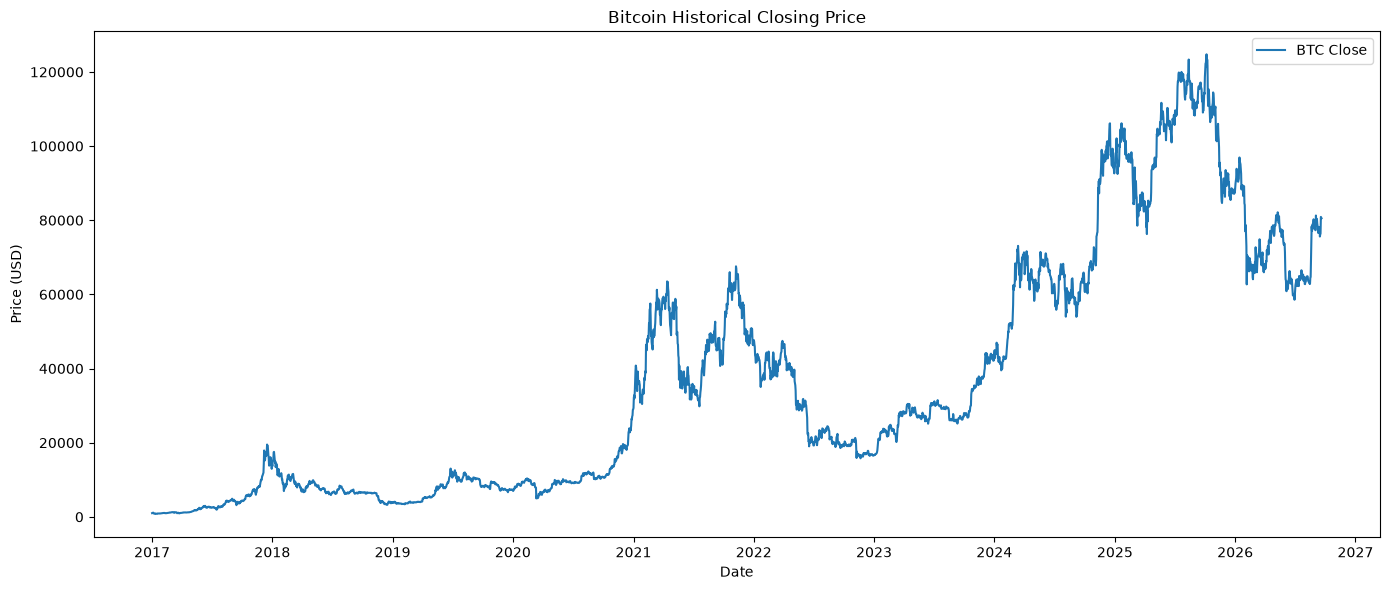

In [7]:
plt.figure(
    figsize=(14, 6)
)

plt.plot(
    df["Date"],
    df["Close"],
    label="BTC Close"
)

plt.title(
    "Bitcoin Historical Closing Price"
)

plt.xlabel("Date")

plt.ylabel(
    "Price (USD)"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    REPORT_DIR /
    "historical_price.png",
    dpi=200
)

plt.show()

In [8]:
feature_df = (
    add_technical_features(df)
)

print(
    "Original shape:",
    df.shape
)

print(
    "Feature shape:",
    feature_df.shape
)

display(
    feature_df.tail()
)

Original shape: (3549, 6)
Feature shape: (3549, 25)


Price,Date,Open,High,Low,Close,Volume,Return_1D,Return_7D,Return_30D,SMA_20,...,MACD_Signal,MACD_Hist,ATR_14,BB_Width,Volatility_20,Volume_Change,Volume_Z_20,Momentum_7,Momentum_30,Target_Close
3544,2026-09-15,78162.484375,78242.546875,74944.593750,75612.507812,39694675220,-0.032635,-0.036029,0.203663,78290.598047,...,2004.325396,-785.052468,2188.286830,0.073151,0.018937,0.327166,1.266546,-2826.070312,12793.855469,76150.320312
3545,2026-09-16,75611.796875,76474.078125,74995.523438,76150.320312,30053315577,0.007113,-0.026951,0.180511,78085.237109,...,1808.186042,-784.557416,2187.523438,0.073220,0.018615,-0.242888,0.241293,-2109.203125,11644.066406,76403.773438
3546,2026-09-17,76152.054688,77079.164062,75945.554688,76403.773438,21917458567,0.003328,-0.002146,0.181245,78013.911328,...,1622.328684,-743.429432,1888.400670,0.075756,0.017455,-0.270714,-0.578460,-164.351562,11723.062500,80901.460938
3547,2026-09-18,76405.015625,81331.765625,76228.328125,80901.460938,40378562386,0.058867,0.048302,0.167979,78146.693750,...,1520.719194,-406.437961,2053.537388,0.082542,0.021964,0.842301,1.388763,3727.664062,11635.273438,80532.007812
3548,2026-09-20,81226.617188,81301.804688,80218.250000,80532.007812,21949454336,-0.004567,0.042209,0.102683,78289.915625,...,1467.880737,-211.353828,2078.830915,0.086500,0.021910,-0.456408,-0.756652,3261.539062,7499.250000,NaN


In [9]:
model_df = (
    feature_df
    .dropna()
    .reset_index(drop=True)
)

print(
    "Usable rows:",
    len(model_df)
)

print(
    "Missing values:",
    model_df.isna().sum().sum()
)

Usable rows: 3518
Missing values: 0


In [10]:
n = len(model_df)

train_end = int(
    n * TRAIN_RATIO
)

val_end = int(
    n * (
        TRAIN_RATIO +
        VAL_RATIO
    )
)

print("Total:", n)
print("Train end:", train_end)
print("Validation end:", val_end)

Total: 3518
Train end: 2462
Validation end: 2990


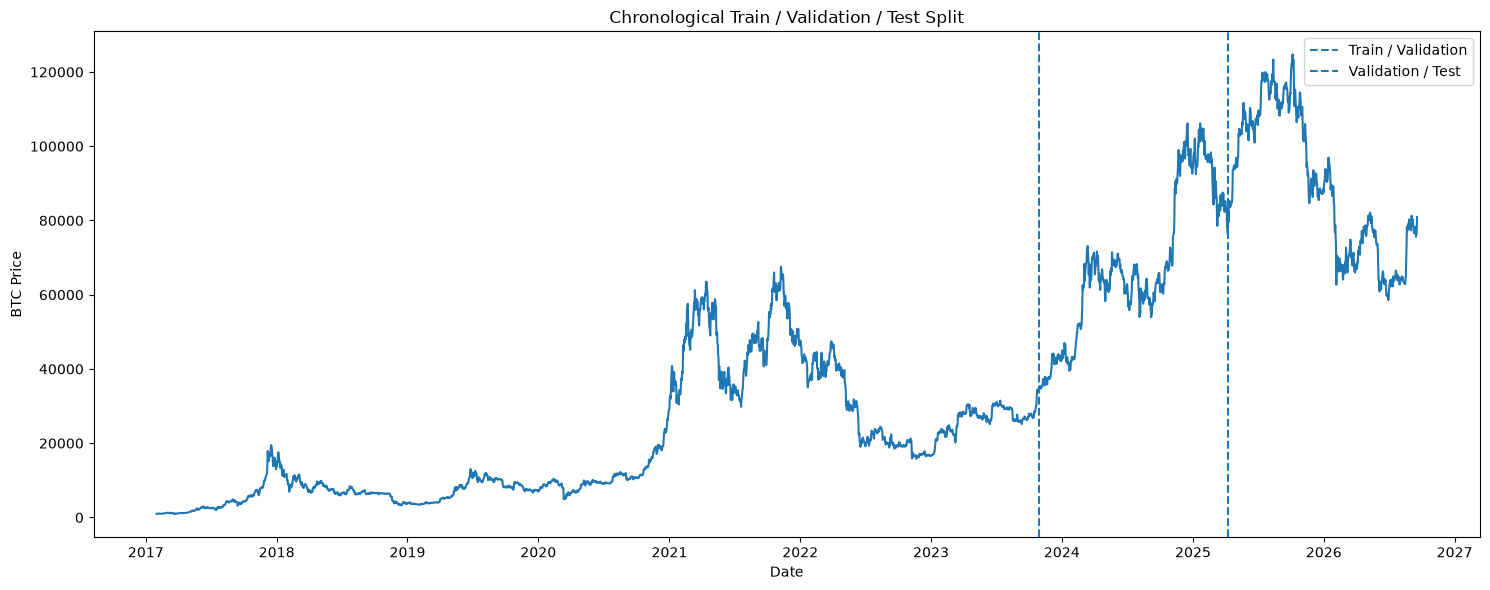

In [11]:
plt.figure(
    figsize=(15, 6)
)

plt.plot(
    model_df["Date"],
    model_df["Close"]
)

plt.axvline(
    model_df["Date"].iloc[
        train_end
    ],
    linestyle="--",
    label="Train / Validation"
)

plt.axvline(
    model_df["Date"].iloc[
        val_end
    ],
    linestyle="--",
    label="Validation / Test"
)

plt.title(
    "Chronological Train / Validation / Test Split"
)

plt.xlabel("Date")

plt.ylabel(
    "BTC Price"
)

plt.legend()

plt.tight_layout()

plt.show()

In [12]:
feature_scaler = (
    StandardScaler()
)

target_scaler = (
    StandardScaler()
)

In [13]:
feature_scaler.fit(
    model_df.loc[
        :train_end - 1,
        FEATURE_COLUMNS
    ]
)

StandardScaler()

In [17]:
scaled_features = (
    feature_scaler.fit_transform(
        model_df[
            FEATURE_COLUMNS
        ]
    )
)

scaled_target = (
    target_scaler.fit_transform(
        model_df[
            ["Target_Close"]
        ]
    )
    .ravel()
)

print(
    "Features:",
    scaled_features.shape
)

print(
    "Target:",
    scaled_target.shape
)

Features: (3518, 23)
Target: (3518,)


In [18]:
X_all = []

y_all = []

target_indices = []

for end_idx in range(
    LOOKBACK - 1,
    len(model_df) - 1
):

    start_idx = (
        end_idx -
        LOOKBACK +
        1
    )

    X_all.append(
        scaled_features[
            start_idx:
            end_idx + 1
        ]
    )

    y_all.append(
        scaled_target[
            end_idx
        ]
    )

    target_indices.append(
        end_idx + 1
    )


X_all = np.asarray(
    X_all,
    dtype=np.float32
)

y_all = np.asarray(
    y_all,
    dtype=np.float32
)

target_indices = np.asarray(
    target_indices
)

print(
    "X shape:",
    X_all.shape
)

print(
    "y shape:",
    y_all.shape
)

X shape: (3458, 60, 23)
y shape: (3458,)


In [20]:
train_mask = (
    target_indices <
    train_end
)

val_mask = (
    (target_indices >= train_end)
    &
    (target_indices < val_end)
)

test_mask = (
    target_indices >= val_end
)

In [21]:
X_train = X_all[
    train_mask
]

y_train = y_all[
    train_mask
]

X_val = X_all[
    val_mask
]

y_val = y_all[
    val_mask
]

X_test = X_all[
    test_mask
]

y_test = y_all[
    test_mask
]

print(
    "Training:",
    X_train.shape
)

print(
    "Validation:",
    X_val.shape
)

print(
    "Testing:",
    X_test.shape
)

Training: (2402, 60, 23)
Validation: (528, 60, 23)
Testing: (528, 60, 23)


In [22]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.float32
)

In [23]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

print(
    "Test batches:",
    len(test_loader)
)

Train batches: 38
Validation batches: 9
Test batches: 9


In [24]:
class CryptoLSTM(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size_1=128,
        hidden_size_2=64,
        dropout=0.25
    ):

        super().__init__()

        self.lstm1 = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size_1,
            batch_first=True
        )

        self.dropout1 = nn.Dropout(
            dropout
        )

        self.lstm2 = nn.LSTM(
            input_size=hidden_size_1,
            hidden_size=hidden_size_2,
            batch_first=True
        )

        self.dropout2 = nn.Dropout(
            0.20
        )

        self.fc1 = nn.Linear(
            hidden_size_2,
            32
        )

        self.relu = nn.ReLU()

        self.output = nn.Linear(
            32,
            1
        )

    def forward(
        self,
        x
    ):

        x, _ = self.lstm1(x)

        x = self.dropout1(x)

        x, _ = self.lstm2(x)

        x = x[:, -1, :]

        x = self.dropout2(x)

        x = self.fc1(x)

        x = self.relu(x)

        x = self.output(x)

        return x.squeeze(1)

In [25]:
model = CryptoLSTM(
    input_size=len(
        FEATURE_COLUMNS
    )
)

model = model.to(
    DEVICE
)

print(model)

CryptoLSTM(
  (lstm1): LSTM(23, 128, batch_first=True)
  (dropout1): Dropout(p=0.25, inplace=False)
  (lstm2): LSTM(128, 64, batch_first=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (output): Linear(in_features=32, out_features=1, bias=True)
)


In [26]:
criterion = nn.HuberLoss(
    delta=1.0
)

In [27]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

In [28]:
scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=4,
        min_lr=1e-6
    )
)

In [29]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):

    model.train()

    total_loss = 0.0

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(
            device
        )

        y_batch = y_batch.to(
            device
        )

        optimizer.zero_grad()

        predictions = model(
            X_batch
        )

        loss = criterion(
            predictions,
            y_batch
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += (
            loss.item() *
            X_batch.size(0)
        )

    return (
        total_loss /
        len(loader.dataset)
    )

In [30]:
def evaluate_loss(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(
                device
            )

            y_batch = y_batch.to(
                device
            )

            predictions = model(
                X_batch
            )

            loss = criterion(
                predictions,
                y_batch
            )

            total_loss += (
                loss.item() *
                X_batch.size(0)
            )

    return (
        total_loss /
        len(loader.dataset)
    )

In [31]:
BEST_MODEL_PATH = (
    ARTIFACT_DIR /
    "best_lstm_model.pth"
)

history = {
    "train_loss": [],
    "val_loss": []
}

best_val_loss = float(
    "inf"
)

best_state = None

epochs_without_improvement = 0


for epoch in range(
    1,
    EPOCHS + 1
):

    train_loss = (
        train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            DEVICE
        )
    )

    val_loss = (
        evaluate_loss(
            model,
            val_loader,
            criterion,
            DEVICE
        )
    )

    scheduler.step(
        val_loss
    )

    history[
        "train_loss"
    ].append(train_loss)

    history[
        "val_loss"
    ].append(val_loss)

    print(
        f"Epoch {epoch:03d} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f} | "
        f"LR: {optimizer.param_groups[0]['lr']:.7f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_state = copy.deepcopy(
            model.state_dict()
        )

        torch.save(
            best_state,
            BEST_MODEL_PATH
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1

    if (
        epochs_without_improvement
        >= PATIENCE
    ):

        print(
            "\nEarly stopping triggered."
        )

        break

Epoch 001 | Train Loss: 0.133346 | Val Loss: 0.364992 | LR: 0.0010000
Epoch 002 | Train Loss: 0.031751 | Val Loss: 0.161737 | LR: 0.0010000
Epoch 003 | Train Loss: 0.024606 | Val Loss: 0.274919 | LR: 0.0010000
Epoch 004 | Train Loss: 0.012079 | Val Loss: 0.174464 | LR: 0.0010000
Epoch 005 | Train Loss: 0.007704 | Val Loss: 0.220030 | LR: 0.0010000
Epoch 006 | Train Loss: 0.006838 | Val Loss: 0.101597 | LR: 0.0010000
Epoch 007 | Train Loss: 0.008551 | Val Loss: 0.319719 | LR: 0.0010000
Epoch 008 | Train Loss: 0.012239 | Val Loss: 0.270059 | LR: 0.0010000
Epoch 009 | Train Loss: 0.008599 | Val Loss: 0.176309 | LR: 0.0010000
Epoch 010 | Train Loss: 0.006199 | Val Loss: 0.147304 | LR: 0.0010000
Epoch 011 | Train Loss: 0.005098 | Val Loss: 0.107128 | LR: 0.0005000
Epoch 012 | Train Loss: 0.004758 | Val Loss: 0.137283 | LR: 0.0005000
Epoch 013 | Train Loss: 0.006252 | Val Loss: 0.118605 | LR: 0.0005000
Epoch 014 | Train Loss: 0.005684 | Val Loss: 0.126719 | LR: 0.0005000
Epoch 015 | Train Lo

In [32]:
model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE
    )
)

model = model.to(
    DEVICE
)

print(
    "Best model loaded."
)

Best model loaded.


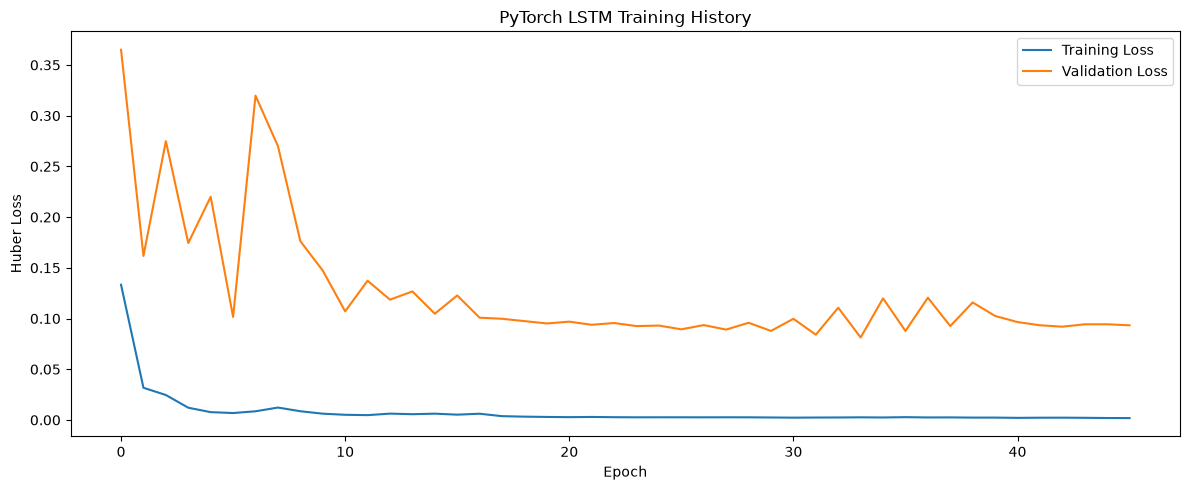

In [33]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "PyTorch LSTM Training History"
)

plt.xlabel("Epoch")

plt.ylabel("Huber Loss")

plt.legend()

plt.tight_layout()

plt.savefig(
    REPORT_DIR /
    "training_history.png",
    dpi=200
)

plt.show()

In [34]:
def predict_loader(
    model,
    loader,
    device
):

    model.eval()

    predictions = []

    actuals = []

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(
                device
            )

            output = model(
                X_batch
            )

            predictions.extend(
                output.cpu()
                .numpy()
            )

            actuals.extend(
                y_batch.numpy()
            )

    return (
        np.asarray(predictions),
        np.asarray(actuals)
    )

In [35]:
predicted_scaled, actual_scaled = (
    predict_loader(
        model,
        test_loader,
        DEVICE
    )
)

print(
    "Predictions:",
    predicted_scaled.shape
)

print(
    "Actual:",
    actual_scaled.shape
)

Predictions: (528,)
Actual: (528,)


In [36]:
predicted_price = (
    target_scaler
    .inverse_transform(
        predicted_scaled.reshape(
            -1,
            1
        )
    )
    .ravel()
)

actual_price = (
    target_scaler
    .inverse_transform(
        actual_scaled.reshape(
            -1,
            1
        )
    )
    .ravel()
)

In [37]:
rmse = np.sqrt(
    mean_squared_error(
        actual_price,
        predicted_price
    )
)

print(
    "RMSE:",
    rmse
)

RMSE: 26367.146830857524


In [38]:
mape = (
    np.mean(
        np.abs(
            (
                actual_price -
                predicted_price
            )
            /
            actual_price
        )
    )
    * 100
)

print(
    "MAPE:",
    mape,
    "%"
)

MAPE: 21.387077 %


In [39]:
r2 = r2_score(
    actual_price,
    predicted_price
)

print(
    "R²:",
    r2
)

R²: -0.9060729742050171


In [40]:
mae = mean_absolute_error(
    actual_price,
    predicted_price
)

print(
    "MAE:",
    mae
)

MAE: 21374.0


In [41]:
test_target_indices = (
    target_indices[
        test_mask
    ]
)

previous_close = (
    model_df[
        "Close"
    ]
    .iloc[
        test_target_indices - 1
    ]
    .values
)

actual_direction = (
    actual_price >
    previous_close
)

predicted_direction = (
    predicted_price >
    previous_close
)

directional_accuracy = (
    actual_direction ==
    predicted_direction
).mean() * 100

print(
    "Directional Accuracy:",
    directional_accuracy,
    "%"
)

Directional Accuracy: 50.0 %


In [42]:
print(
    "\n========== MODEL RESULTS =========="
)

print(
    f"RMSE: ${rmse:,.2f}"
)

print(
    f"MAE: ${mae:,.2f}"
)

print(
    f"MAPE: {mape:.2f}%"
)

print(
    f"R²: {r2:.4f}"
)

print(
    f"Directional Accuracy: "
    f"{directional_accuracy:.2f}%"
)


========== MODEL RESULTS ==========
RMSE: $26,367.15
MAE: $21,374.00
MAPE: 21.39%
R²: -0.9061
Directional Accuracy: 50.00%


In [43]:
naive_prediction = (
    previous_close.copy()
)

naive_mae = (
    mean_absolute_error(
        actual_price,
        naive_prediction
    )
)

naive_rmse = np.sqrt(
    mean_squared_error(
        actual_price,
        naive_prediction
    )
)

print(
    "Naive MAE:",
    naive_mae
)

print(
    "Naive RMSE:",
    naive_rmse
)

Naive MAE: 1335.459043560606
Naive RMSE: 1876.2945166469335


In [44]:
mae_improvement = (
    1 -
    (
        mae /
        naive_mae
    )
) * 100

print(
    "LSTM MAE:",
    mae
)

print(
    "Naive MAE:",
    naive_mae
)

print(
    "MAE difference relative to naive:",
    mae_improvement,
    "%"
)

LSTM MAE: 21374.0
Naive MAE: 1335.459043560606
MAE difference relative to naive: -1500.498353211384 %


In [45]:
test_dates = (
    model_df[
        "Date"
    ]
    .iloc[
        test_target_indices
    ]
    .values
)

comparison = pd.DataFrame({
    "Date": test_dates,
    "Actual": actual_price,
    "Predicted": predicted_price
})

display(
    comparison.head()
)

,Date,Actual,Predicted
0,2025-04-09,82573.953125,64997.921875
1,2025-04-10,79626.140625,65809.304688
2,2025-04-11,83404.828125,65868.789062
3,2025-04-12,85287.109375,66583.500000
4,2025-04-13,83684.968750,67373.929688


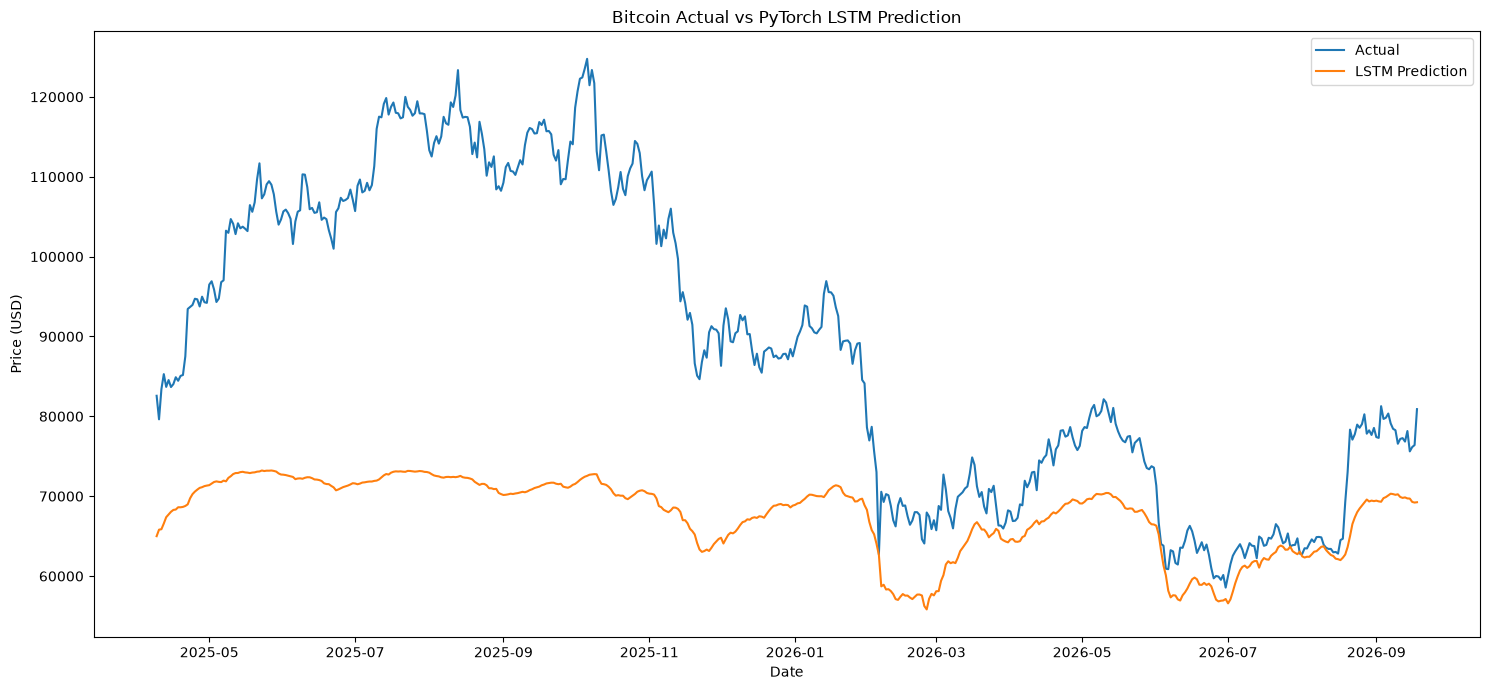

In [46]:
plt.figure(
    figsize=(15, 7)
)

plt.plot(
    comparison["Date"],
    comparison["Actual"],
    label="Actual"
)

plt.plot(
    comparison["Date"],
    comparison["Predicted"],
    label="LSTM Prediction"
)

plt.title(
    "Bitcoin Actual vs PyTorch LSTM Prediction"
)

plt.xlabel("Date")

plt.ylabel(
    "Price (USD)"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    REPORT_DIR /
    "actual_vs_predicted.png",
    dpi=200
)

plt.show()

In [48]:
residuals = (
    actual_price -
    predicted_price
)

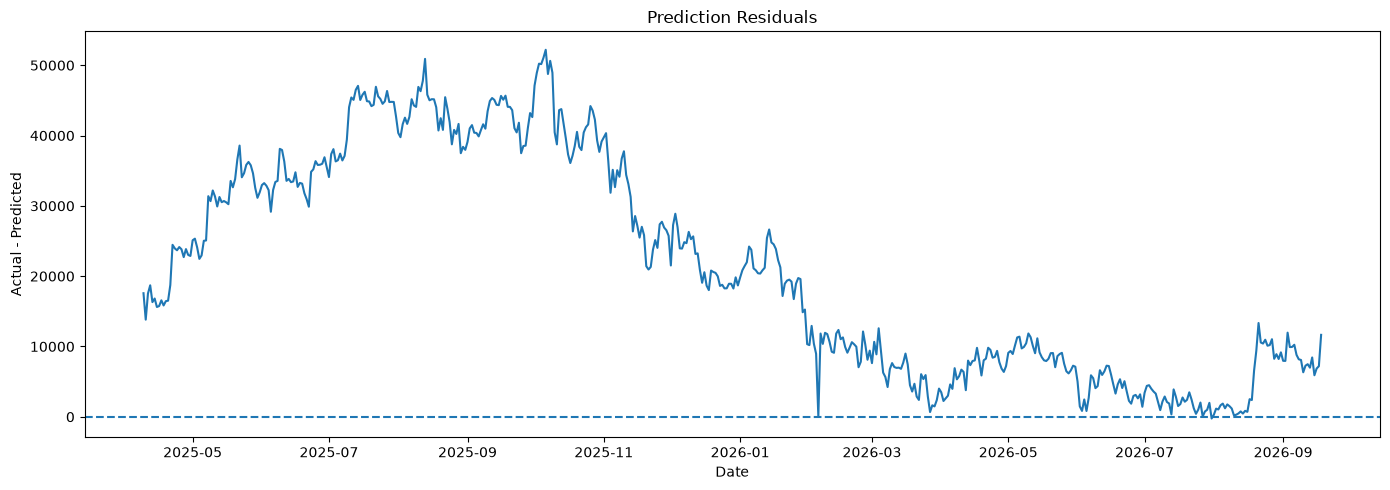

In [49]:
plt.figure(
    figsize=(14, 5)
)

plt.plot(
    test_dates,
    residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "Prediction Residuals"
)

plt.xlabel("Date")

plt.ylabel(
    "Actual - Predicted"
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR /
    "residuals.png",
    dpi=200
)

plt.show()

In [50]:
error_analysis = (
    comparison.copy()
)

error_analysis[
    "Absolute_Error"
] = (
    error_analysis[
        "Actual"
    ]
    -
    error_analysis[
        "Predicted"
    ]
).abs()

error_analysis = (
    error_analysis
    .sort_values(
        "Absolute_Error",
        ascending=False
    )
)

display(
    error_analysis.head(10)
)

,Date,Actual,Predicted,Absolute_Error
180,2025-10-06,124752.531250,72548.500000,52204.031250
179,2025-10-05,123513.476562,72438.656250,51074.820312
126,2025-08-13,123344.054688,72436.531250,50907.523438
182,2025-10-08,123354.867188,72726.140625,50628.726562
177,2025-10-03,122266.523438,72040.937500,50225.585938
178,2025-10-04,122425.429688,72257.703125,50167.726562
183,2025-10-09,121705.585938,72767.984375,48937.601562
176,2025-10-02,120681.257812,71772.390625,48908.867188
181,2025-10-07,121451.382812,72690.914062,48760.468750
125,2025-08-12,120172.906250,72385.210938,47787.695312


In [51]:
def mc_dropout_prediction(
    model,
    X_tensor,
    target_scaler,
    device,
    n_samples=60
):

    model.train()

    predictions = []

    X_tensor = X_tensor.to(
        device
    )

    with torch.no_grad():

        for _ in range(
            n_samples
        ):

            output = model(
                X_tensor
            )

            predictions.append(
                output.cpu()
                .numpy()
            )

    predictions = np.asarray(
        predictions
    )

    prices = (
        target_scaler
        .inverse_transform(
            predictions.reshape(
                -1,
                1
            )
        )
        .reshape(
            predictions.shape
        )
    )

    mean_prediction = (
        prices.mean(axis=0)
    )

    lower_bound = (
        np.percentile(
            prices,
            5,
            axis=0
        )
    )

    upper_bound = (
        np.percentile(
            prices,
            95,
            axis=0
        )
    )

    model.eval()

    return (
        mean_prediction,
        lower_bound,
        upper_bound
    )

In [52]:
latest_test_X = (
    X_test_tensor[-1:]
)

mean_prediction, lower_bound, upper_bound = (
    mc_dropout_prediction(
        model,
        latest_test_X,
        target_scaler,
        DEVICE,
        n_samples=60
    )
)

print(
    "Mean prediction:",
    mean_prediction[0]
)

print(
    "Lower bound:",
    lower_bound[0]
)

print(
    "Upper bound:",
    upper_bound[0]
)

Mean prediction: 68428.35
Lower bound: 63181.145
Upper bound: 72103.555


In [53]:
joblib.dump(
    feature_scaler,
    ARTIFACT_DIR /
    "feature_scaler.pkl"
)

joblib.dump(
    target_scaler,
    ARTIFACT_DIR /
    "target_scaler.pkl"
)

print(
    "Scalers saved."
)

Scalers saved.


In [54]:
model_config = {
    "ticker": TICKER,
    "lookback": LOOKBACK,
    "feature_columns": FEATURE_COLUMNS,
    "input_size": len(
        FEATURE_COLUMNS
    ),
    "hidden_size_1": 128,
    "hidden_size_2": 64,
    "dropout_1": 0.25,
    "dropout_2": 0.20,
    "dense_size": 32
}

with open(
    ARTIFACT_DIR /
    "model_config.json",
    "w"
) as file:

    json.dump(
        model_config,
        file,
        indent=4
    )

print(
    "Configuration saved."
)

Configuration saved.


In [55]:
metrics = {
    "ticker": TICKER,
    "rmse": float(rmse),
    "mae": float(mae),
    "mape_percent": float(mape),
    "r2": float(r2),
    "directional_accuracy_percent":
        float(
            directional_accuracy
        ),
    "naive_rmse": float(
        naive_rmse
    ),
    "naive_mae": float(
        naive_mae
    ),
    "relative_mae_difference_percent":
        float(
            mae_improvement
        ),
    "generated_at":
        datetime.now().isoformat()
}

with open(
    ARTIFACT_DIR /
    "metadata.json",
    "w"
) as file:

    json.dump(
        metrics,
        file,
        indent=4
    )

print(
    "Metrics saved."
)

Metrics saved.


In [56]:
live_df = download_crypto(
    ticker=TICKER,
    start="2024-01-01"
)

live_features = (
    add_technical_features(
        live_df
    )
    .dropna()
    .reset_index(drop=True)
)

print(
    "Latest market date:",
    live_features[
        "Date"
    ].iloc[-1]
)

print(
    "Latest close:",
    live_features[
        "Close"
    ].iloc[-1]
)

Latest market date: 2026-09-18 00:00:00
Latest close: 80901.4609375


In [57]:
latest_sequence = (
    live_features[
        FEATURE_COLUMNS
    ]
    .tail(LOOKBACK)
)

latest_scaled = (
    feature_scaler.transform(
        latest_sequence
    )
)

latest_X = torch.tensor(
    latest_scaled,
    dtype=torch.float32
).unsqueeze(0)

print(
    "Live sequence shape:",
    latest_X.shape
)

Live sequence shape: torch.Size([1, 60, 23])


In [58]:
mean_prediction, lower_bound, upper_bound = (
    mc_dropout_prediction(
        model,
        latest_X,
        target_scaler,
        DEVICE,
        n_samples=60
    )
)

current_price = (
    live_features[
        "Close"
    ].iloc[-1]
)

forecast_price = (
    mean_prediction[0]
)

expected_change = (
    (
        forecast_price -
        current_price
    )
    /
    current_price
) * 100

print(
    "Current BTC price:",
    current_price
)

print(
    "Next-day model estimate:",
    forecast_price
)

print(
    "Estimated percentage difference:",
    expected_change,
    "%"
)

print(
    "Lower uncertainty bound:",
    lower_bound[0]
)

print(
    "Upper uncertainty bound:",
    upper_bound[0]
)

Current BTC price: 80901.4609375
Next-day model estimate: 69322.234
Estimated percentage difference: -14.31275335243386 %
Lower uncertainty bound: 65544.99
Upper uncertainty bound: 73736.33
